# Hidden CKD

#### Variables
- Date of event: Date of the screening
- Gender: Gender of the patient (M: Male, F: Female)
- Ethnicity: The ethnicity of the participant
- D.O.B.: The date of birth of the participant
- Age: Age of the patient (years)
- Height (cm): Height of the participant in cm
- Weight (kg): Weight of the participant in kg
- BMI: BMI of the participant
- BMI Category: Classification of the particpant BMI according to NICE guidelines
- Systolic, Diastolic: The systolic and diastolic of the partcipants
- BP Category: Classification of the particpant BP according to NICE guidelines
- Medical Conditions: Medical conditions the patient has (High blood pressure, Diabetes, Kidney disease, Heart disease and Other
- What medications/tablets are you currently taking?: The kinds of medication the participants are taking (Cholesterol, BP, Diabetes, Other)
- Name of blood pressure medication / Tablets
- Name of blood pressure medication / Tablets
- Name of blood pressure medication / Tablets
- Do you have a family history of kidney disease?: Whether or not the participant has a family history of kidney disease
- uACR: uACR level of the participant (Normal, Abnormal, High Abnormal)

In [1]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR

2025-07-29 14:15:24.621 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/Edward/Documents/GitHub/hidden-ckd


In [2]:
filename = PROCESSED_DATA_DIR / 'hidden_ckd_processed.csv'
data = pd.read_csv(filename)
data.head()

,Date,Gender,Ethnicity,S_Ethnicity,Ethnicity_Black,DOB,Age,Age_Category,Height,Weight,...,Has_Diabetes,Has_KD,Has_HD,BP_Meds,Diabetes_Meds,Cholesterol_Meds,Other_Meds,Family_KD,uACR,CKD_Risk
0,23/10/2022,Male,Black Caribbean,Black,True,21/05/1946,76.5,>70,161.0,64.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
1,23/10/2022,Male,Black African (West Africa),Black,True,25/01/1970,52.8,41-55,163.0,78.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
2,26/08/2023,Male,Black Caribbean,Black,True,14/07/2005,18.1,<25,167.0,91.0,...,False,False,False,False,False,False,False,Definitely not,Normal,Low
3,28/04/2023,Male,Black Caribbean,Black,True,25/04/1969,54.0,41-55,168.0,87.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
4,06/11/2022,Female,Black African (West Africa),Black,True,03/11/1979,43.0,41-55,187.0,109.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate


# **Exploratory Data Analysis**

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [4]:
data.describe()

,Age,Height,Weight,BMI,Systolic,Diastolic,Pulse_Pressure
count,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000
mean,50.901457,165.813309,81.799761,29.841207,136.210198,82.668054,53.542144
std,14.165017,9.140738,15.422907,5.720421,20.212144,11.863947,15.003352
min,14.400000,111.500000,45.500000,19.000000,88.000000,45.000000,11.000000
25%,42.100000,159.000000,71.000000,25.800000,123.000000,75.000000,44.000000
50%,52.900000,165.000000,80.200000,29.200000,134.000000,82.000000,52.000000
75%,60.300000,171.000000,90.000000,32.900000,146.000000,90.000000,61.000000
max,92.100000,198.000000,169.000000,62.100000,243.000000,141.000000,154.000000


In [5]:
#pairwise Pearson correlations between numeric variables
data[['Age', 'Height', 'Weight', 'BMI', 'Systolic', 'Diastolic']].corr()

,Age,Height,Weight,BMI,Systolic,Diastolic
Age,1.000000,-0.148845,0.040848,0.126661,0.275041,0.131094
Height,-0.148845,1.000000,0.300835,-0.291076,0.027621,0.048182
Weight,0.040848,0.300835,1.000000,0.816627,0.178478,0.206016
BMI,0.126661,-0.291076,0.816627,1.000000,0.157471,0.178603
Systolic,0.275041,0.027621,0.178478,0.157471,1.000000,0.675957
Diastolic,0.131094,0.048182,0.206016,0.178603,0.675957,1.000000


In [6]:
#creating a function to group variables

def group_stats(column_name):
    '''
    Groups the data and runs some basic stats
    '''
    table = {
        column_name: data[column_name].sort_values().unique(),
        'Mean Age': data.groupby(column_name)['Age'].mean().round(2),
        'Mean Height (cm)': data.groupby(column_name)['Height'].mean().round(2),
        'Mean Weight (kg)': data.groupby(column_name)['Weight'].mean().round(2),
        'Mean BMI': data.groupby(column_name)['BMI'].mean().round(2),
        'Mean Systolic': data.groupby(column_name)['Systolic'].mean().round(2),
        'Mean Diastolic': data.groupby(column_name)['Diastolic'].mean().round(2),
        'Normal uACR Counts': data[(data['uACR'] == 'Normal')].groupby([column_name]).size(),
        'Abnormal uACR Counts': data[(data['uACR'] == 'Abnormal')].groupby([column_name]).size(),
        'High Abnormal uACR Counts': data[(data['uACR'] == 'High Abnormal')].groupby([column_name]).size(),
        }
    table = pd.DataFrame(table).set_index(column_name).fillna(0)
    table = table.astype({'Normal uACR Counts': 'int', 'Abnormal uACR Counts': 'int', 'High Abnormal uACR Counts': 'int'})
    return table

In [7]:
eth_data = group_stats('Ethnicity')
eth_data

,Mean Age,Mean Height (cm),Mean Weight (kg),Mean BMI,Mean Systolic,Mean Diastolic,Normal uACR Counts,Abnormal uACR Counts,High Abnormal uACR Counts
Ethnicity,,,,,,,,,
Any other,53.28,170.88,97.35,33.10,133.25,82.25,3,1,0
Asian other,50.09,168.34,84.01,29.66,128.96,78.87,15,7,1
Bangladeshi,59.20,167.91,80.63,28.44,152.71,84.71,6,1,0
Black African (Central Africa),51.42,168.65,83.70,29.49,138.00,83.93,10,5,0
Black African (East Africa),47.48,163.08,78.08,29.44,128.24,79.24,10,9,2
Black African (North Africa),54.88,170.75,77.33,26.58,130.00,80.83,5,1,0
Black African (South Africa),46.72,164.92,82.48,30.28,126.00,78.50,1,5,0
Black African (West Africa),50.98,166.03,81.88,29.79,136.51,82.84,264,198,37
Black African (unspecified),51.32,164.79,81.33,30.13,136.57,83.36,77,62,10


In [8]:
eth_data_simplified = group_stats('S_Ethnicity')
eth_data_simplified

,Mean Age,Mean Height (cm),Mean Weight (kg),Mean BMI,Mean Systolic,Mean Diastolic,Normal uACR Counts,Abnormal uACR Counts,High Abnormal uACR Counts
S_Ethnicity,,,,,,,,,
Asian other,50.09,168.34,84.01,29.66,128.96,78.87,15,7,1
Black,50.88,165.83,81.55,29.75,136.17,82.66,430,335,52
Mixed,56.42,163.27,82.89,31.05,140.85,82.67,18,12,3
Other,53.28,170.88,97.35,33.10,133.25,82.25,3,1,0
South Asian,52.01,168.48,82.23,29.08,141.31,84.91,25,7,0
White,47.23,164.03,82.64,30.78,134.21,83.06,39,11,2


In [9]:
gender_data = group_stats('Gender')
gender_data

,Mean Age,Mean Height (cm),Mean Weight (kg),Mean BMI,Mean Systolic,Mean Diastolic,Normal uACR Counts,Abnormal uACR Counts,High Abnormal uACR Counts
Gender,,,,,,,,,
Female,51.20,165.57,81.31,29.74,136.80,82.57,276,237,27
Male,50.52,166.12,82.43,29.97,135.46,82.80,254,136,31


In [10]:
age_data = group_stats('Age_Category').iloc[[3,0,1,2,4], :]
age_data

,Mean Age,Mean Height (cm),Mean Weight (kg),Mean BMI,Mean Systolic,Mean Diastolic,Normal uACR Counts,Abnormal uACR Counts,High Abnormal uACR Counts
Age_Category,,,,,,,,,
<25,21.80,168.81,74.43,26.11,126.37,75.19,37,15,0
25-40,33.32,167.09,79.95,28.70,127.67,80.11,100,45,12
41-55,48.45,166.07,84.44,30.67,136.43,83.81,198,141,15
56-70,61.02,165.06,81.79,30.15,139.54,84.20,162,143,22
>70,76.71,162.97,78.17,29.56,145.89,81.03,33,29,9


In [11]:
bp_cat_data = group_stats('BP_Category').iloc[[3,4,0,1,2], :]
bp_cat_data

,Mean Age,Mean Height (cm),Mean Weight (kg),Mean BMI,Mean Systolic,Mean Diastolic,Normal uACR Counts,Abnormal uACR Counts,High Abnormal uACR Counts
BP_Category,,,,,,,,,
NORMAL,48.26,165.70,79.84,29.16,123.15,75.95,318,197,25
PRE HPT,53.67,165.82,83.43,30.49,144.04,88.72,76,70,10
HPT 1,53.57,165.79,84.34,30.81,151.25,90.05,110,73,14
HPT 2,58.33,167.53,86.83,30.94,174.63,98.81,23,28,8
HPT CRISIS,54.60,161.84,82.59,31.43,202.78,113.67,3,5,1


In [12]:
fam_data = group_stats('Family_KD')
fam_data

,Mean Age,Mean Height (cm),Mean Weight (kg),Mean BMI,Mean Systolic,Mean Diastolic,Normal uACR Counts,Abnormal uACR Counts,High Abnormal uACR Counts
Family_KD,,,,,,,,,
Definitely not,50.55,165.40,81.09,29.72,134.60,82.09,263,219,29
Definitely yes,50.80,166.41,80.62,29.09,135.81,81.42,22,11,3
Not sure,51.35,166.27,82.78,30.06,138.23,83.50,245,143,26


In [13]:
fig = px.histogram(data, x='BP_Category', y='Age', color='Gender', barmode='group', histfunc='avg',
             facet_row='uACR', facet_col='Family_KD',
             category_orders={'Family_KD': ['Definitely yes', 'Definitely not', 'Not sure'],
                              'uACR': ['Normal', 'Abnormal', 'High Abnormal']})

fig.update_layout(
    autosize=False,
    width=1100,
    height=500,
    margin=dict(l=20, r=20, t=50, b=20),
)

fig.show()

In [14]:
hist_features = ['Age', 'Height', 'Weight', 'BMI', 'Systolic', 'Diastolic']

plot = go.Figure(data=[go.Histogram(name=i, x=data[i], nbinsx = 10)
                       for i in hist_features])


# Add dropdown 
plot.update_layout( 
	updatemenus=[ 
		dict( 
			direction="down",
			buttons=list([ 
				dict(label=i, 
					method="update", 
					args=[{"visible": [i == j for j in hist_features]}, 
						{"title": i}])
                for i in hist_features
			]), 
		) 
	]) 

# Add annotation
plot.update_layout(
    annotations=[
        dict(text="Feature:", showarrow=False,
        x = -0.15, xref="paper", y=1.075, yref="paper", align="left")
    ]
)

plot.update_layout(
    autosize=False,
    width=1100,
    height=350,
    margin=dict(l=20, r=20, t=50, b=20),
)

plot.show() 

In [15]:
# Variables
x_var = 'uACR'
y_var = 'Age'
k_var = ['Family_KD', 'BMI_Category', 'BP_Category', 'S_Ethnicity', 'Gender']

fig = go.Figure()

# Add traces for each combination of k_var values
for a in k_var:
    for k in data[a].unique():
        fig.add_trace(
            go.Bar(
                name=f'{k}',
                x=data[x_var].unique(),
                y=[data[y_var][(data[x_var] == x) & (data[a] == k)].mean() for x in data[x_var].unique()],
                visible=a == k_var[0]
            )
        )

# Create buttons for each k_var
buttons = []
for a in k_var:
    buttons.append(dict(
        method='update',
        label=a,
        args=[{
            'visible': [a == current for current in k_var for _ in data[current].unique()],
            'title': f'Mean Age by {a} and uACR'
        }]
    ))

# Update layout with dropdown
fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction='down',
            showactive=True
        )
    ],
    barmode='group',
    title='Mean Age by Selected Variable and uACR',
    xaxis_title='uACR',
    yaxis_title='Mean Age'
)

# Update plot size
fig.update_layout(
    autosize=False,
    width=1100,
    height=350,
    margin=dict(l=20, r=20, t=50, b=20),
)

fig.show()


In [16]:
# List of dataframes
dfs = [bp_cat_data, age_data, gender_data, fam_data, eth_data_simplified]
df_names = ['BP Categories', 'Age Ranges', 'Genders', 'Family KD', 'Ethnicities']

# Default dataframe
df = dfs[0]

# Variables
x_var = df.index
y_var = df[['Mean Age', 'Mean Height (cm)', 'Mean Weight (kg)', 'Mean BMI', 'Mean Systolic', 'Mean Diastolic']]

# Create the initial figure
plot = go.Figure()

# Add traces for each y_var
for i in y_var.columns:
    plot.add_trace(
        go.Bar(name=i, x=x_var, y=y_var[i], visible=i == 'Mean Age')
    )

# Add dropdown menus
plot.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(label=df_name,
                     method='update',
                     args=[{'x': [dfs[df_names.index(df_name)].index] * len(y_var.columns),
                            'y': [dfs[df_names.index(df_name)][col] for col in y_var.columns],
                            'visible': [i == y_var.columns[0] for i in y_var.columns]},
                           {'title': f'{y_var.columns[0]} by {df_name}'}])
                for df_name in df_names
            ]),
            direction='down',
            showactive=True,
            x=-0.2,
            xanchor='left',
            y=0.9,
            yanchor='top'
        ),
        dict(
            buttons=list([
                dict(label=i,
                     method='update',
                     args=[{'visible': [i == j for j in y_var.columns]},
                           {'title': f'{i} by {df_names[0]}'}])
                for i in y_var.columns
            ]),
            direction='down',
            showactive=True,
            x=-0.2,
            xanchor='left',
            y=0.6,
            yanchor='top'
        )
    ]
)

# Add annotation
plot.update_layout(
    annotations=[
        dict(text="Select Data:", showarrow=False,
             x=-0.2, xref="paper", y=1, yref="paper", align="left"),
        dict(text="Select Feature:", showarrow=False,
             x=-0.2, xref="paper", y=0.7, yref="paper", align="left")
    ],
    autosize=False,
    width=1100,
    height=350,
    margin=dict(l=20, r=20, t=50, b=20),
    title=dict(text='Univariate Analysis', x=0.01)
)

plot.show()

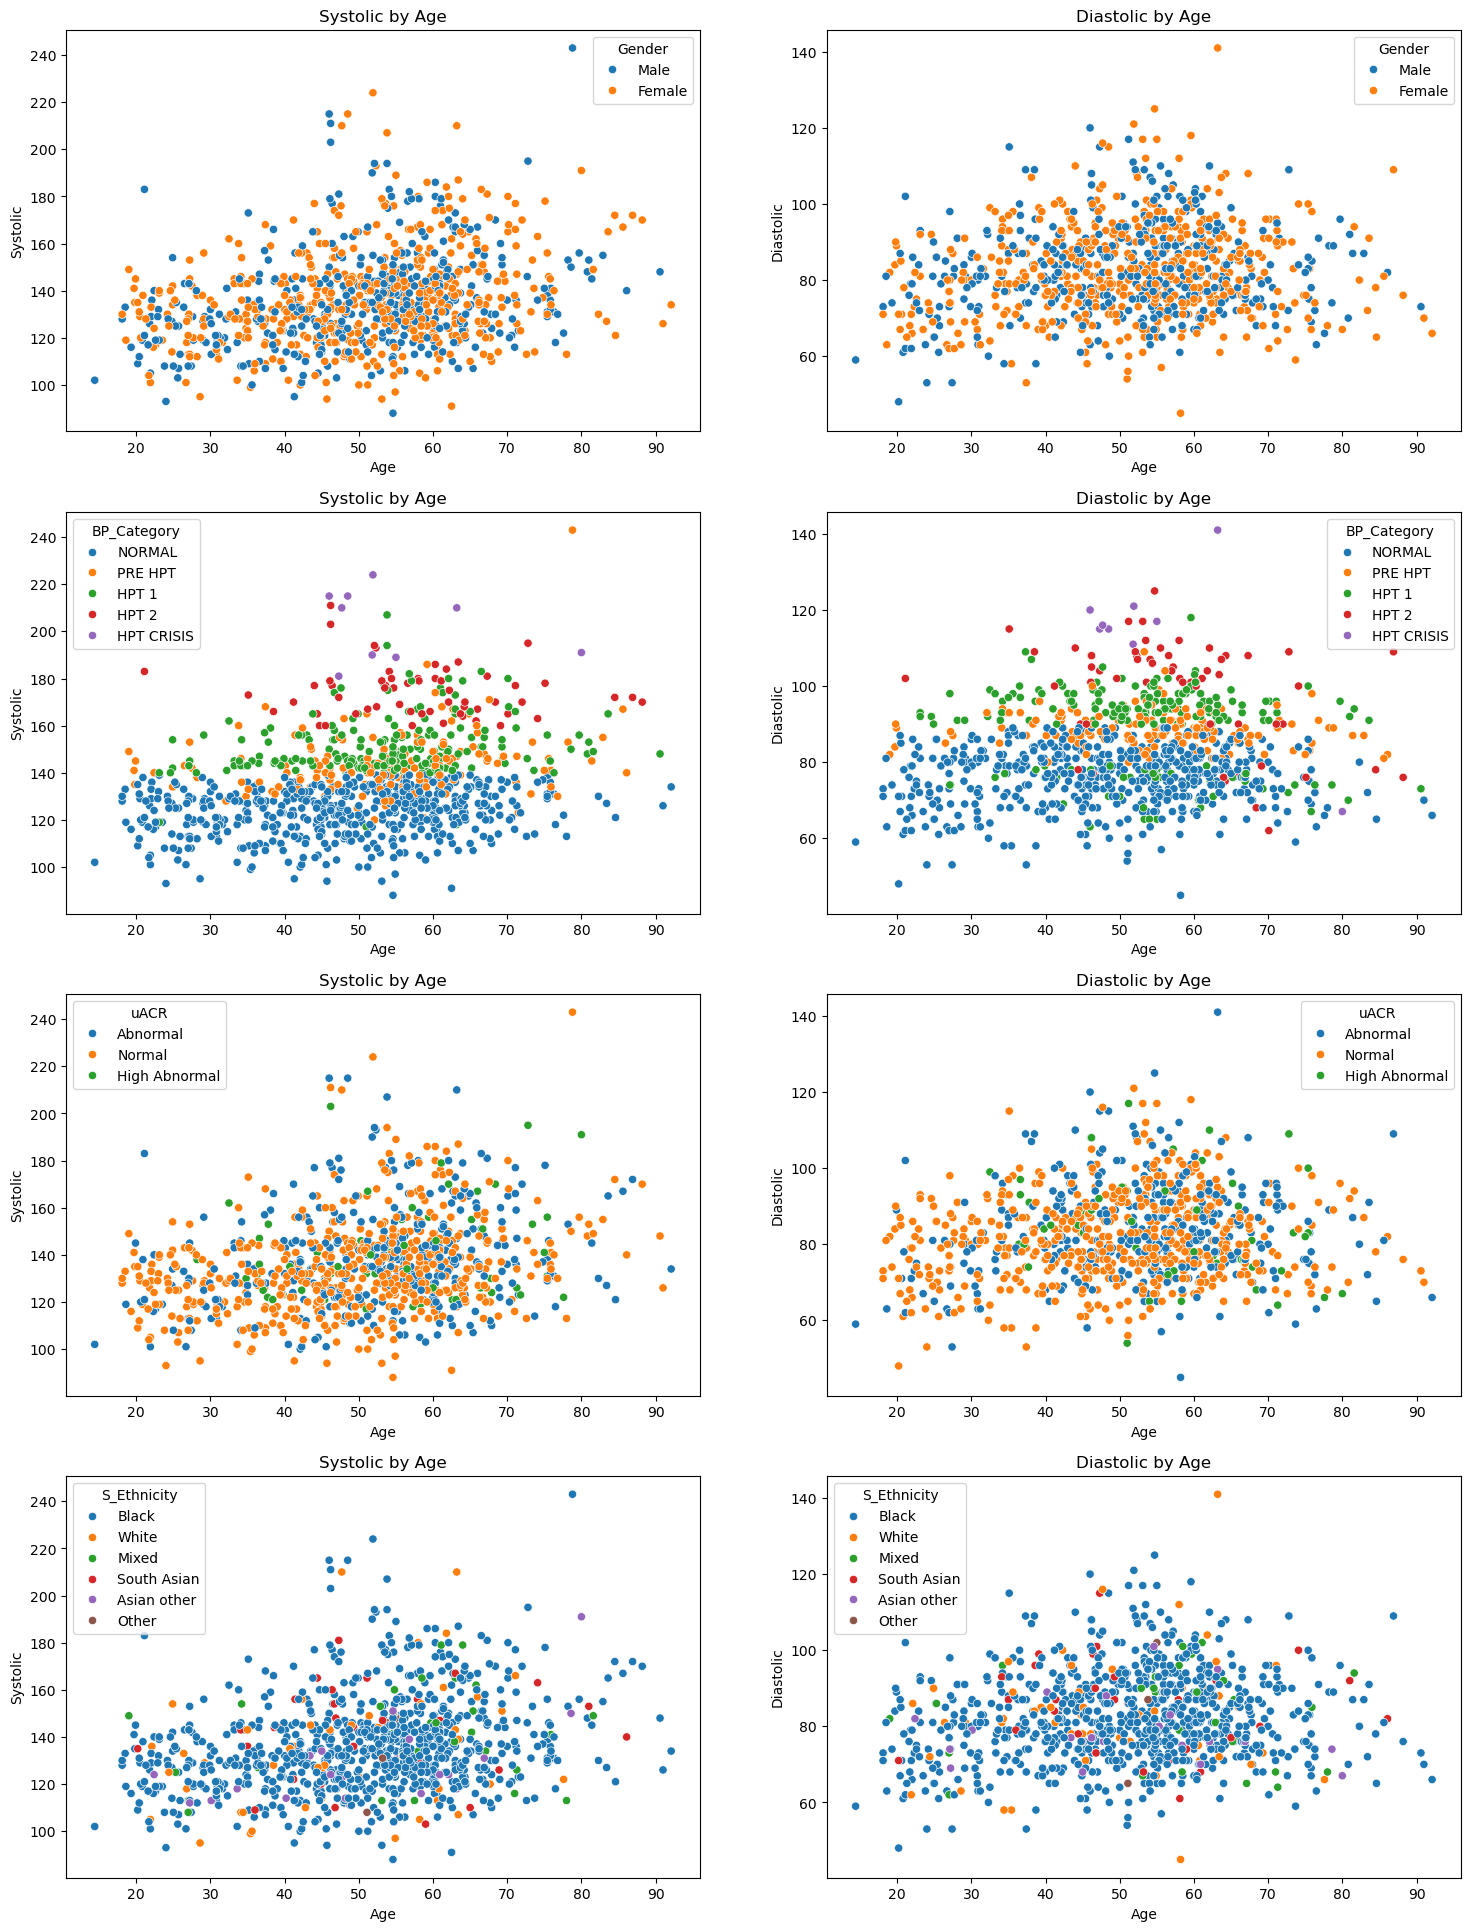

In [17]:
plt.figure(figsize = (18, 24))

plt.subplot(4, 2, 1)
sns.scatterplot(data=data, x='Age', y='Systolic', hue = 'Gender')
plt.title("Systolic by Age")

plt.subplot(4, 2, 2)
sns.scatterplot(data=data, x='Age', y='Diastolic', hue = 'Gender')
plt.title("Diastolic by Age")

plt.subplot(4, 2, 3)
sns.scatterplot(data=data, x='Age', y='Systolic', hue = 'BP_Category')
plt.title("Systolic by Age")

plt.subplot(4, 2, 4)
sns.scatterplot(data=data, x='Age', y='Diastolic', hue = 'BP_Category')
plt.title("Diastolic by Age")

plt.subplot(4, 2, 5)
sns.scatterplot(data=data, x='Age', y='Systolic', hue = 'uACR')
plt.title("Systolic by Age")

plt.subplot(4, 2, 6)
sns.scatterplot(data=data, x='Age', y='Diastolic', hue = 'uACR')
plt.title("Diastolic by Age")

plt.subplot(4, 2, 7)
sns.scatterplot(data=data, x='Age', y='Systolic', hue = 'S_Ethnicity')
plt.title("Systolic by Age")

plt.subplot(4, 2, 8)
sns.scatterplot(data=data, x='Age', y='Diastolic', hue = 'S_Ethnicity')
plt.title("Diastolic by Age")

%matplotlib inline
plt.show()

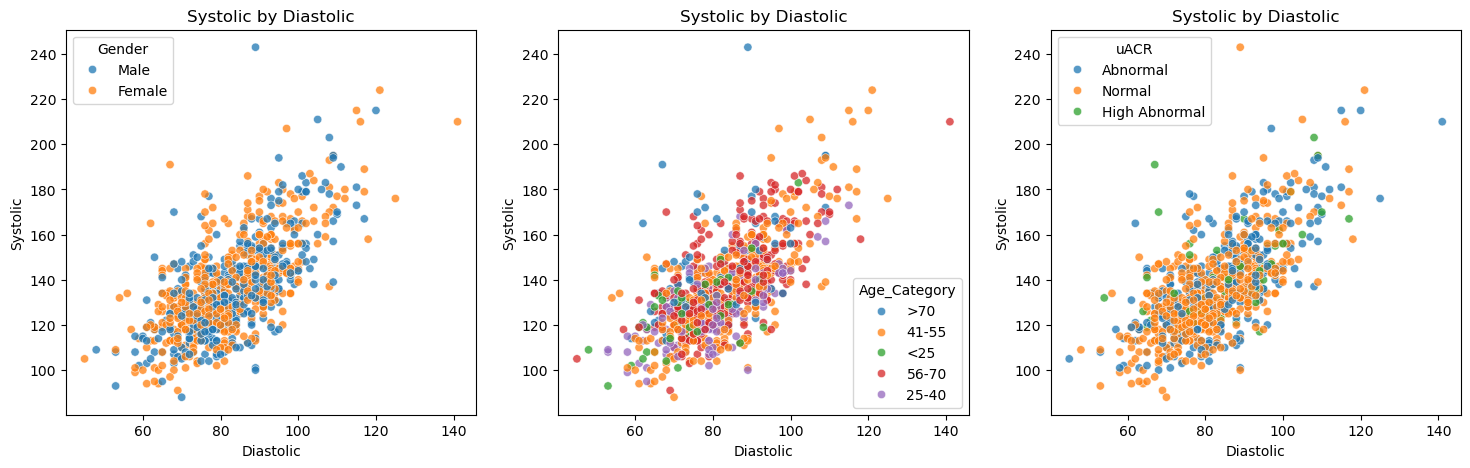

In [18]:
plt.figure(figsize = (18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='Diastolic', y='Systolic', hue = 'Gender', alpha=0.75)
plt.title("Systolic by Diastolic")

plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='Diastolic', y='Systolic', hue = 'Age_Category', alpha=0.75)
plt.title("Systolic by Diastolic")

plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='Diastolic', y='Systolic', hue = 'uACR', alpha=0.75)
plt.title("Systolic by Diastolic")

%matplotlib inline
plt.show()

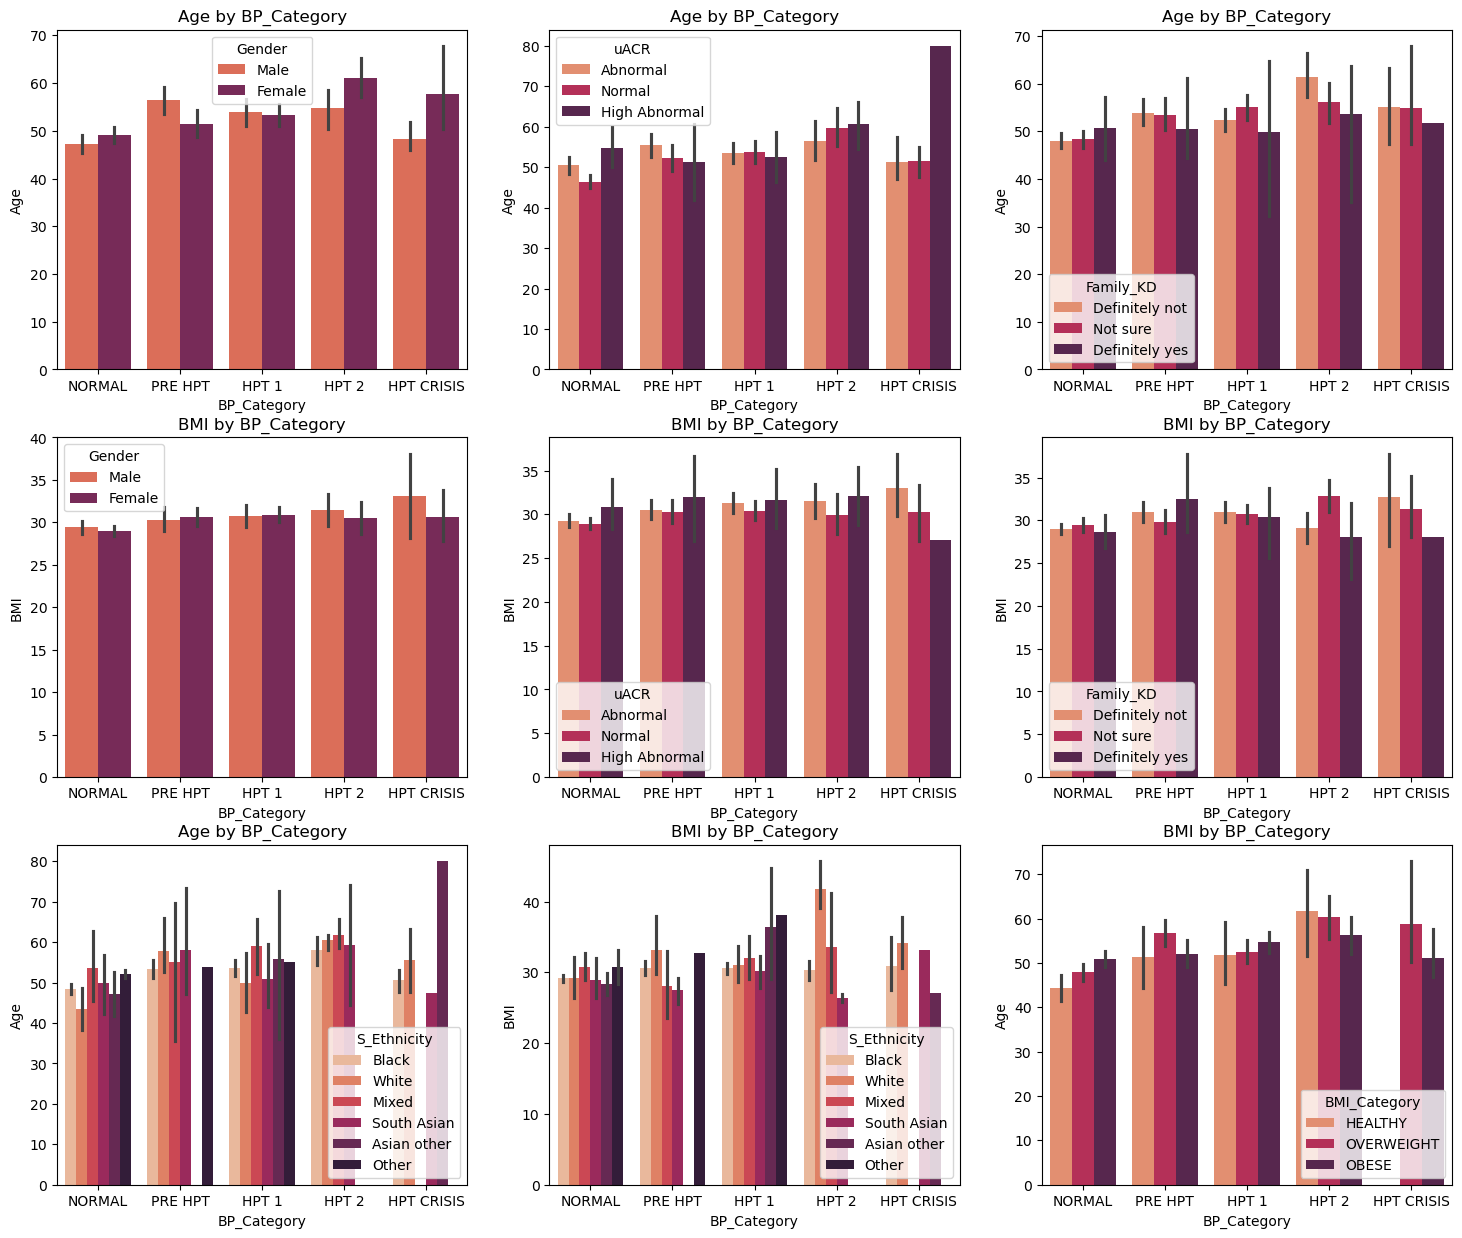

In [19]:
plt.figure(figsize = (18, 15))

plt.subplot(3, 3, 1)
sns.barplot(data=data, x='BP_Category', y='Age', palette='rocket_r', hue = 'Gender')
plt.title("Age by BP_Category")

plt.subplot(3, 3, 2)
sns.barplot(data=data, x='BP_Category', y='Age', palette='rocket_r', hue = 'uACR')
plt.title("Age by BP_Category")

plt.subplot(3, 3, 3)
sns.barplot(data=data, x='BP_Category', y='Age', palette='rocket_r', hue = 'Family_KD')
plt.title("Age by BP_Category")

plt.subplot(3, 3, 4)
sns.barplot(data=data, x='BP_Category', y='BMI', palette='rocket_r', hue = 'Gender')
plt.title("BMI by BP_Category")

plt.subplot(3, 3, 5)
sns.barplot(data=data, x='BP_Category', y='BMI', palette='rocket_r', hue = 'uACR')
plt.title("BMI by BP_Category")

plt.subplot(3, 3, 6)
sns.barplot(data=data, x='BP_Category', y='BMI', palette='rocket_r', hue = 'Family_KD')
plt.title("BMI by BP_Category")

plt.subplot(3, 3, 7)
sns.barplot(data=data, x='BP_Category', y='Age', palette='rocket_r', hue = 'S_Ethnicity')
plt.title("Age by BP_Category")

plt.subplot(3, 3, 8)
sns.barplot(data=data, x='BP_Category', y='BMI', palette='rocket_r', hue = 'S_Ethnicity')
plt.title("BMI by BP_Category")

plt.subplot(3, 3, 9)
sns.barplot(data=data, x='BP_Category', y='Age', palette='rocket_r', hue = 'BMI_Category')
plt.title("BMI by BP_Category")

plt.show()

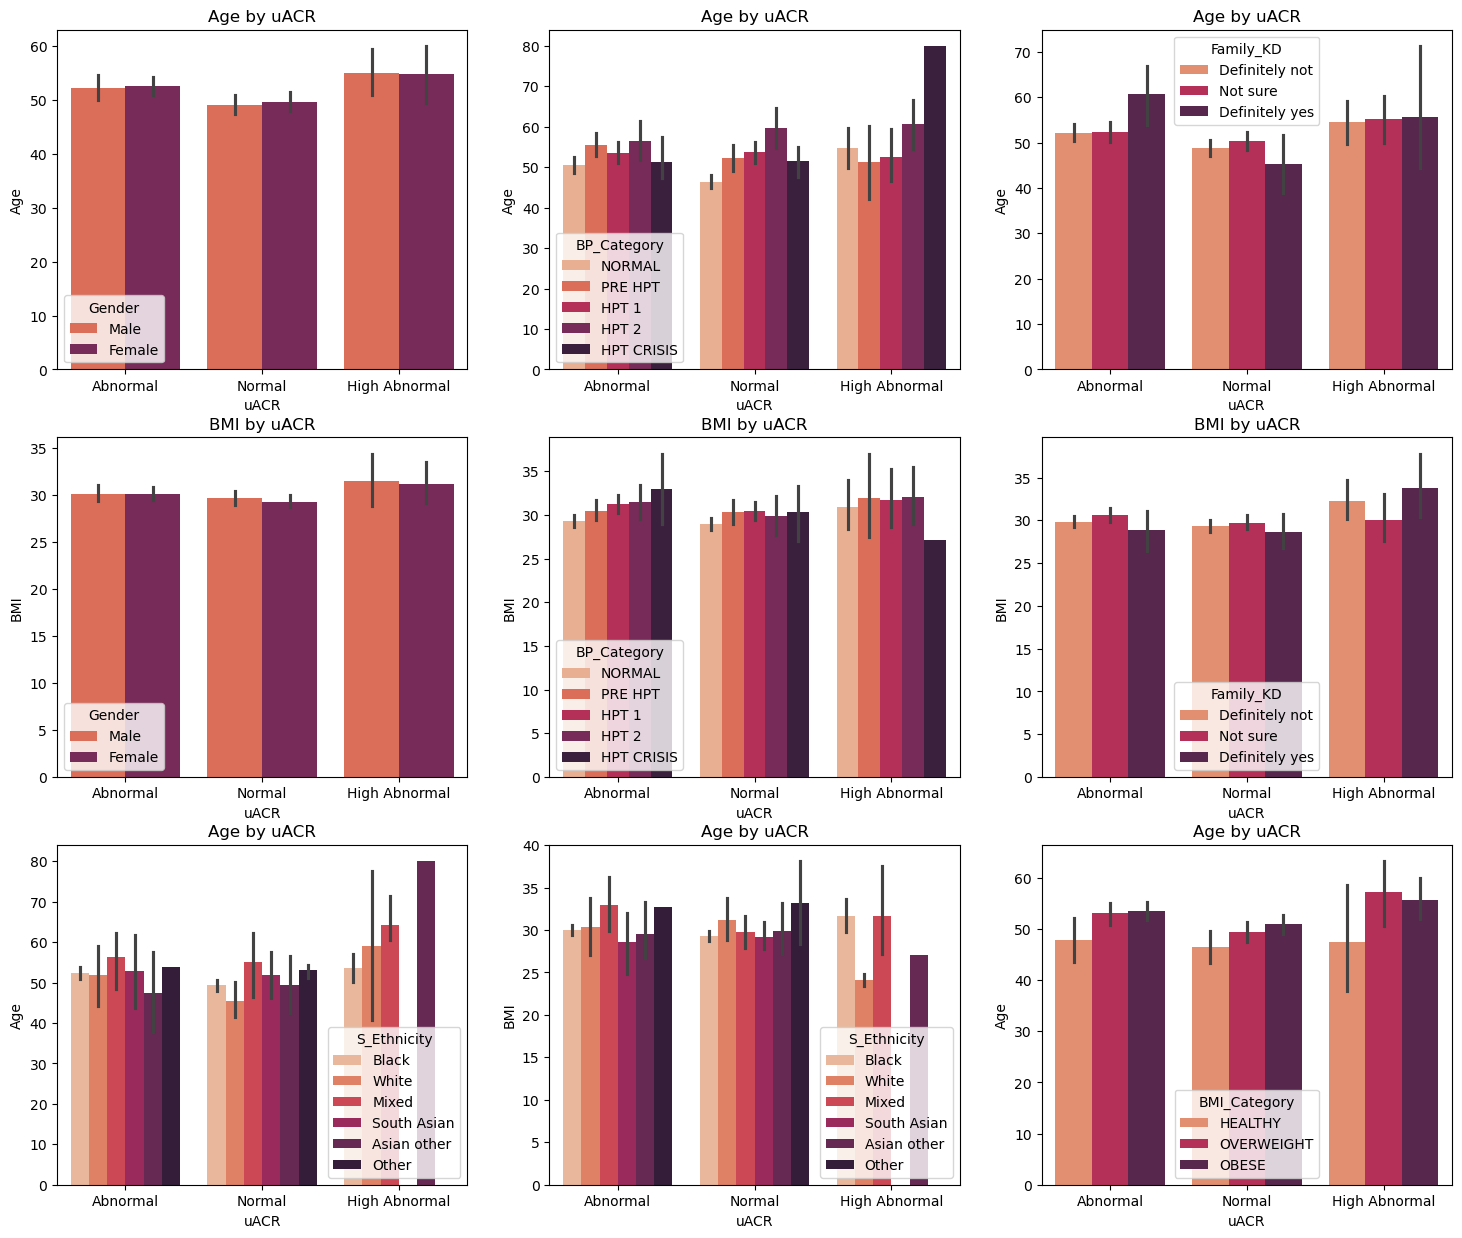

In [20]:
plt.figure(figsize = (18, 15))

plt.subplot(3, 3, 1)
sns.barplot(data=data, x='uACR', y='Age', palette='rocket_r', hue = 'Gender')
plt.title("Age by uACR")

plt.subplot(3, 3, 2)
sns.barplot(data=data, x='uACR', y='Age', palette='rocket_r', hue = 'BP_Category')
plt.title("Age by uACR")

plt.subplot(3, 3, 3)
sns.barplot(data=data, x='uACR', y='Age', palette='rocket_r', hue = 'Family_KD')
plt.title("Age by uACR")

plt.subplot(3, 3, 4)
sns.barplot(data=data, x='uACR', y='BMI', palette='rocket_r', hue = 'Gender')
plt.title("BMI by uACR")

plt.subplot(3, 3, 5)
sns.barplot(data=data, x='uACR', y='BMI', palette='rocket_r', hue = 'BP_Category')
plt.title("BMI by uACR")

plt.subplot(3, 3, 6)
sns.barplot(data=data, x='uACR', y='BMI', palette='rocket_r', hue = 'Family_KD')
plt.title("BMI by uACR")

plt.subplot(3, 3, 7)
sns.barplot(data=data, x='uACR', y='Age', palette='rocket_r', hue = 'S_Ethnicity')
plt.title("Age by uACR")

plt.subplot(3, 3, 8)
sns.barplot(data=data, x='uACR', y='BMI', palette='rocket_r', hue = 'S_Ethnicity')
plt.title("Age by uACR")

plt.subplot(3, 3, 9)
sns.barplot(data=data, x='uACR', y='Age', palette='rocket_r', hue = 'BMI_Category')
plt.title("Age by uACR")

%matplotlib inline
plt.show()

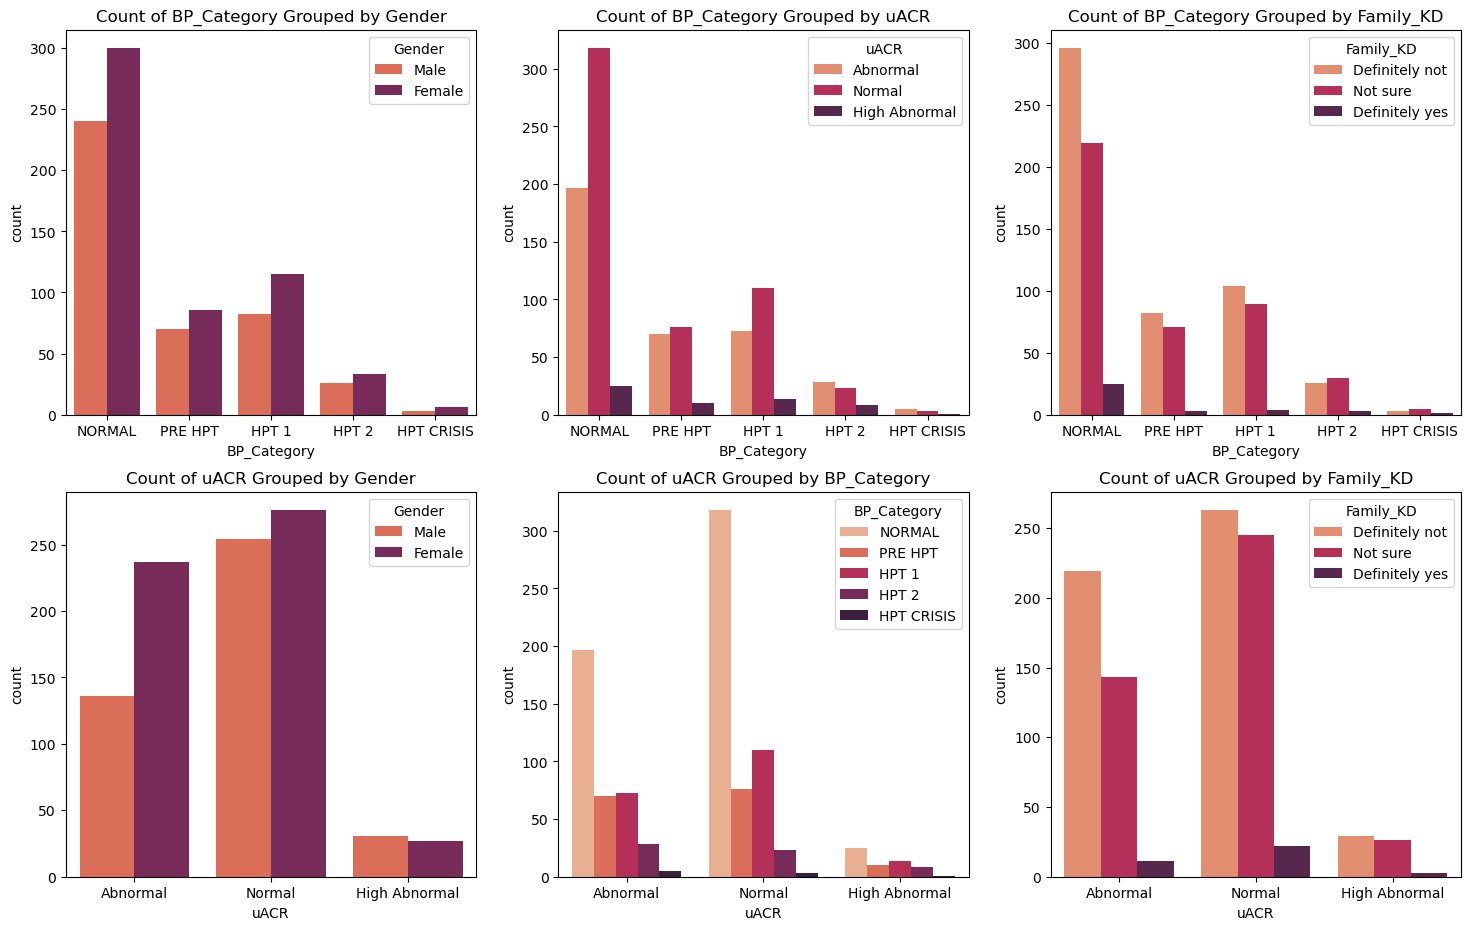

In [21]:
plt.figure(figsize = (18, 11))

plt.subplot(2, 3, 1)
sns.countplot(data=data, x='BP_Category', palette='rocket_r', hue = 'Gender')
plt.title("Count of BP_Category Grouped by Gender")

plt.subplot(2, 3, 2)
sns.countplot(data=data, x='BP_Category', palette='rocket_r', hue = 'uACR')
plt.title("Count of BP_Category Grouped by uACR")

plt.subplot(2, 3, 3)
sns.countplot(data=data, x='BP_Category', palette='rocket_r', hue = 'Family_KD')
plt.title("Count of BP_Category Grouped by Family_KD")

plt.subplot(2, 3, 4)
sns.countplot(data=data, x='uACR', palette='rocket_r', hue = 'Gender')
plt.title("Count of uACR Grouped by Gender")

plt.subplot(2, 3, 5)
sns.countplot(data=data, x='uACR', palette='rocket_r', hue = 'BP_Category')
plt.title("Count of uACR Grouped by BP_Category")

plt.subplot(2, 3, 6)
sns.countplot(data=data, x='uACR', palette='rocket_r', hue = 'Family_KD')
plt.title("Count of uACR Grouped by Family_KD")

%matplotlib inline
plt.show()